## Micrograd 
following Andrej Karpathy's yt video - https://youtu.be/VMj-3S1tku0?si=Q7-pE2EtAaUVmxIC  

### always ask:
* grad of global out w.r.t. local out, and grad of local ins w.r.t. local out


In [101]:
import math
import random
import numpy as np
from graphviz import Digraph
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
def f(x):
    return 3*x**2 - 4*x + 5

In [6]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

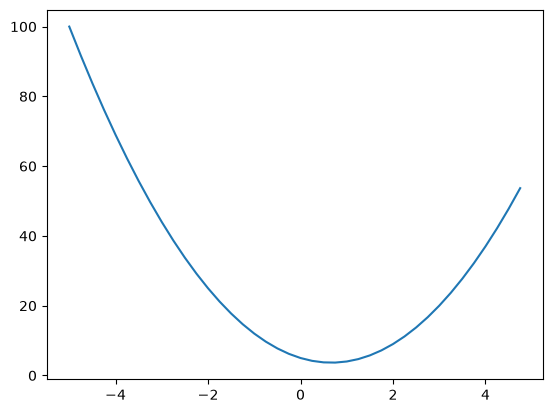

In [7]:
plt.plot(xs, ys)

In [8]:
h = 0.001
x = 3.0
(f(x + h) - f(x)) / h

14.00300000000243

In [132]:
class Value:
    def __init__(self, data, _children=(), _op='', _label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self._label = _label

    def __repr__(self):
        return f"value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "under construction: only supporting int or float"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data**(other - 1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * (other**-1)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for c in v._prev:
                    build_topo(c)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [10]:
a = Value(2.0)
print(a)

value(data=2.0)


In [11]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for c in v._prev:
                edges.add((c, v))
                build(c)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n._label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot
            

as the definition of derivative is
$$
\lim_{h \to 0}\frac{f(x+h)-f(x)}{h}
$$
we can approximate it with taking *tiny* $h$

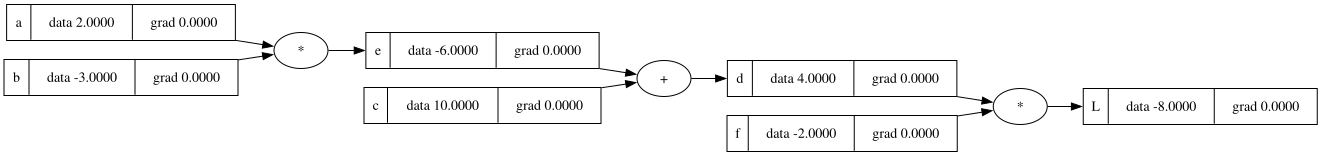

In [12]:
a = Value(2.0, _label = 'a')
b = Value(-3.0, _label = 'b')
c = Value(10, _label = 'c')
e = a*b; e._label = 'e'
d = e + c; d._label = 'd'
f = Value(-2.0, _label = 'f')
L = d*f; L._label='L'
draw_dot(L)

In [13]:
# inline gradient check

def lol():
    h = 0.0001
    
    a = Value(2.0, _label = 'a')
    b = Value(-3.0, _label = 'b')
    c = Value(10, _label = 'c')
    e = a*b; e._label = 'e'
    d = e + c; d._label = 'd'
    f = Value(-2.0, _label = 'f')
    L = d*f; L._label='L'
    L1 = L.data

    a = Value(2.0, _label = 'a')
    b = Value(-3.0, _label = 'b')
    c = Value(10, _label = 'c')
    e = a*b; e._label = 'e'
    d = e + c; d._label = 'd'
    f = Value(-2.0, _label = 'f')
    L = d*f; L._label='L'
    L2 = L.data

    print(f"{BOLD}{BLUE}gradient comes out to be: {(L2 - L1) / h}{RESET}")
lol()

gradient comes out to be: 0.0


for $\partial{L}/\partial{c}$ the chain rule tells us the relation
$$
\frac{\partial{L}}{\partial{c}} = \frac{\partial{L}}{\partial{d}}\frac{\partial{d}}{\partial{c}} 
$$
for $\partial{L}/\partial{e}$ the chain rule tells us the relation
$$
\frac{\partial{L}}{\partial{e}} = \frac{\partial{L}}{\partial{d}}\frac{\partial{d}}{\partial{e}} 
$$
for $\partial{L}/\partial{a}$ the chain rule tells us the relation
$$
\frac{\partial{L}}{\partial{a}} = \frac{\partial{L}}{\partial{e}}\frac{\partial{e}}{\partial{a}} 
$$
for $\partial{L}/\partial{b}$ the chain rule tells us the relation
$$
\frac{\partial{L}}{\partial{b}} = \frac{\partial{L}}{\partial{e}}\frac{\partial{e}}{\partial{b}} 
$$

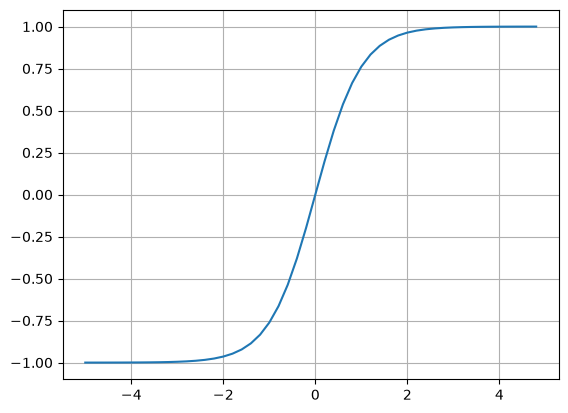

In [18]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

focus on a simple **perceptron**

In [91]:
# inputs
x1 = Value(2.0, _label='x1')
x2 = Value(0.0, _label='x2')

# weights
w1 = Value(-3.0, _label='w1')
w2 = Value(1.0, _label='w2')

# bias
b = Value(6.8813735870195432, _label='b')

x1w1 = x1*w1; x1w1._label='x1w1'
x2w2 = x2*w2; x2w2._label='x2w2'
x1w1plusx2w2 = x1w1+x2w2; x1w1plusx2w2._label='x1w1 + x2w2'
n = x1w1plusx2w2 + b; n._label='n'
o = n.tanh(); o._label='o'


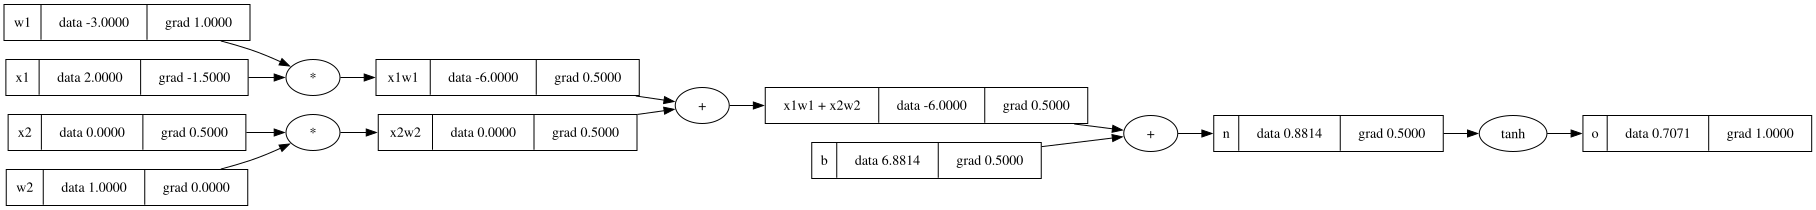

In [94]:
draw_dot(o)

lets propogate the derivatives of this graph

$$
\frac{\partial{L}}{\partial{n}} = \frac{\partial{}}{\partial{n}}tanh(n)
= 1 - tanh^{2}(n)
$$

we infer that
$$
\frac{\partial{n}}{\partial{(x_1w_1)}} = 1
$$
similarly
$$
\frac{\partial{n}}{\partial{(x_2w_2)}} = 1
$$
and also
$$
\frac{\partial{n}}{\partial{b}} = 1
$$
and
$$
\frac{\partial{n}}{\partial{x_1}} = w_1
$$
$$
\frac{\partial{n}}{\partial{x_2}} = w_2
$$
$$
\frac{\partial{n}}{\partial{w_1}} = x_1
$$
$$
\frac{\partial{n}}{\partial{w_2}} = x_2
$$
and hence
$$
\frac{\partial{L}}{\partial{b}} = \frac{\partial{L}}{\partial{n}}\frac{\partial{n}}{\partial{b}}
$$
$$
\frac{\partial{L}}{\partial{x_1}} = \frac{\partial{L}}{\partial{n}}\frac{\partial{n}}{\partial{x_1}}
$$
$$
\frac{\partial{L}}{\partial{x_2}} = \frac{\partial{L}}{\partial{n}}\frac{\partial{n}}{\partial{x_2}}
$$
$$
\frac{\partial{L}}{\partial{w_1}} = \frac{\partial{L}}{\partial{n}}\frac{\partial{n}}{\partial{w_1}}
$$
$$
\frac{\partial{L}}{\partial{w_2}} = \frac{\partial{L}}{\partial{n}}\frac{\partial{n}}{\partial{w_2}}
$$

so in the following cells we call the appropriate backprop functions, after initializing the value of $\partial{L}/\partial{L}$ equal to 1

In [82]:
o.grad = 1

In [83]:
o._backward()

In [84]:
n._backward()

In [85]:
b._backward()

In [86]:
x1w1plusx2w2._backward()

In [87]:
x1w1._backward()

In [88]:
x2w2._backward()

great, but we want to automate this.  
for which we will use **topo sort**.  
</br>
but we are doing simple **dfs** here... it does the job, because we know the **start point**, and it is a **dag**

In [93]:
o.backward()

**now I understand how the differentiation features of libraries work**  
lets take an api of torch for example purpose


In [61]:
import torch

In [95]:
# Ik that tensor syntax has changed,...
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print_separator()

print('x1', x1.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())

0.7071066904050358
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


### An example MLP class

In [142]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((w*x for x, w in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



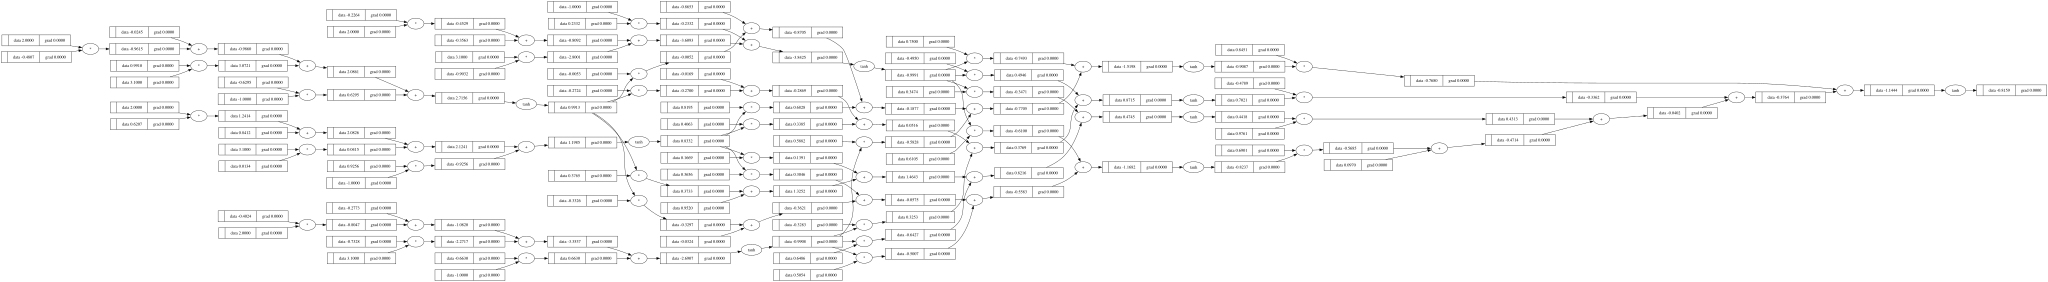

In [143]:
x = [2.0, 3.1, -1]
n = MLP(3, [4, 4, 1])
n(x)
draw_dot(n(x))

In [144]:
n.parameters()

[value(data=-0.480725279872918),
 value(data=0.9910101489527909),
 value(data=-0.6294913262340165),
 value(data=-0.024533806092348787),
 value(data=0.620714424157371),
 value(data=0.013377858105579676),
 value(data=0.9256141025871056),
 value(data=0.8412096010689616),
 value(data=-0.40236165241726907),
 value(data=-0.7328166924827058),
 value(data=-0.6630330061733447),
 value(data=-0.27727726475229075),
 value(data=-0.2264493810209427),
 value(data=-0.9032452754608213),
 value(data=0.2332445902423197),
 value(data=-0.35633760301025563),
 value(data=-0.3326219526249745),
 value(data=0.3655573349069179),
 value(data=0.5053720031760727),
 value(data=0.6105374802946142),
 value(data=-0.03237583385786347),
 value(data=0.376535537958534),
 value(data=0.166931495940009),
 value(data=0.6486493635234245),
 value(data=0.34740400849468145),
 value(data=0.9519693254536217),
 value(data=-0.2724032485736012),
 value(data=0.40630608028679394),
 value(data=-0.3283207157936545),
 value(data=-0.49503347

In [177]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0 ],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0]

In [178]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

value(data=2.073432667723122)

In [154]:
loss.backward()

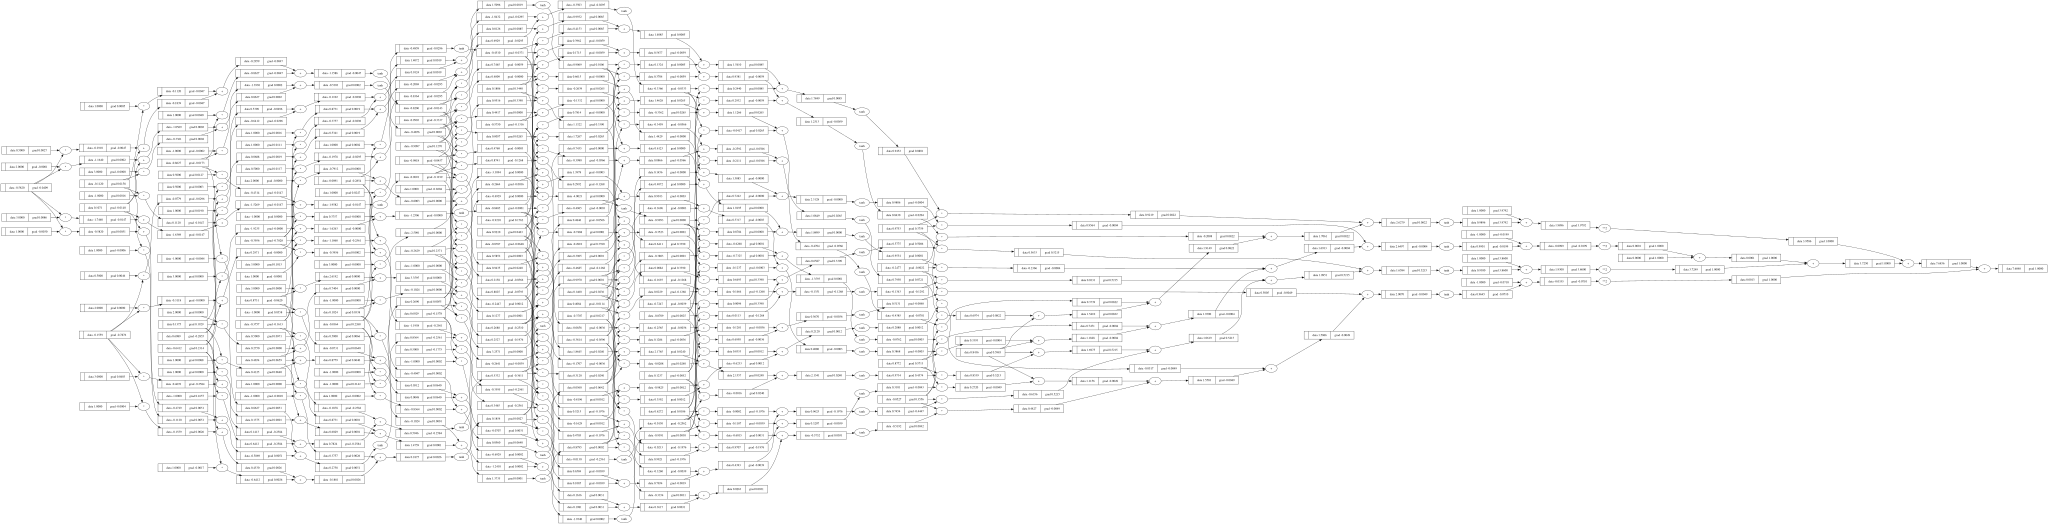

In [140]:
draw_dot(loss)

### Training

In [184]:
learning_rate = 0.9

epochs = 200
for e in range(epochs):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    loss.backward()

    # update params and flush grad
    for p in n.parameters():
        p.data += p.grad * learning_rate * (-1)
        p.grad = 0.0

    print(e, loss.data)

0 0.00021003785525092227
1 0.0002082676736561184
2 0.00020652581401888015
3 0.00020481161975980075
4 0.00020312445408649527
5 0.00020146369926268127
6 0.00019982875590915811
7 0.00019821904233504898
8 0.00019663399389786655
9 0.0001950730623908746
10 0.00019353571545651074
11 0.00019202143602449514
12 0.00019052972177351858
13 0.00018906008461529454
14 0.00018761205019994707
15 0.00018618515744172186
16 0.00018477895806402625
17 0.00018339301616292116
18 0.0001820269077881863
19 0.00018068022054118168
20 0.00017935255318862962
21 0.00017804351529173212
22 0.0001767527268498174
23 0.0001754798179578769
24 0.00017422442847741875
25 0.00017298620771997824
26 0.0001717648141427746
27 0.00017055991505593072
28 0.00016937118634081144
29 0.00016819831217892476
30 0.0001670409847909552
31 0.00016589890418555273
32 0.00016477177791734228
33 0.00016365932085383948
34 0.00016256125495094206
35 0.00016147730903645922
36 0.00016040721860158448
37 0.0001593507255997394
38 0.00015830757825269613
39 0

In [ ]:
# =============================================================================================================== #
#                                                FORMATTING CELL                                                  #
# =============================================================================================================== #
RESET = "\033[0m"
BOLD = "\033[1m"

RED = "\033[31m"
GREEN = "\033[32m"
YELLOW = "\033[33m"
BLUE = "\033[34m"
CYAN = "\033[36m"

print(f"{BOLD}{RED}ERROR:{RESET} Something went wrong")
print(f"{GREEN}Success!{RESET}")

def print_separator():
    print(f"{RED}================================================================================{RESET}")